# Reproduzindo Detecção com Transfer Learning

## 1. Recap UA1 + UA2 Classificação → Detecção

Em UA1: Imagem → Classe (é um gato? sim/não)
Em UA2-01: Imagem → Classe com confiança (93% gato)
**Agora:** Imagem → [Bbox1, Bbox2, ...] com classes e confiança

### Por que usar Transfer Learning em Detecção?

- Datasets de detecção são caros (anotação pixel-perfeita)
- Modelos pré-treinados em COCO (330K imagens, 80 classes) aprenderam excelentes features
- Fine-tuning em dados específicos leva horas vs. semanas do zero

## 2. Objetivo e Entregáveis

**Você vai:**
1. Carregar um dataset COCO (ou subset)
2. Fine-tunar Faster R-CNN pré-treinada
3. Gerar predições e visualizações
4. Calcular mAP e outras métricas
5. Documentar insights em `resultados/`

**Arquivos a entregar:**
- `metricas_deteccao.json`
- `predicoes_visualizadas.png`
- `relatorio_deteccao.json`

## 3. Imports e Setup

In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, models
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import time
from pathlib import Path
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent.parent))

# Import shared utilities
from _shared.repro import set_seed
from _shared.paths import get_data_dir, get_results_dir, get_models_dir
from _shared.io import save_json, load_json

# Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

# Set reproducibility
set_seed(42)

# IMPORTANT: Pass the exercise root explicitly for notebooks
EXERCISE_ROOT = Path.cwd()
print(f"✅ Exercise root: {EXERCISE_ROOT}")

# Directory management with explicit root
OUTPUT_DIR = get_results_dir(EXERCISE_ROOT)
MODELS_DIR = get_models_dir(EXERCISE_ROOT)
DATA_DIR = get_data_dir(EXERCISE_ROOT)

print(f"✅ Output directory: {OUTPUT_DIR}")
print(f"✅ Models directory: {MODELS_DIR}")
print(f"✅ Data directory: {DATA_DIR}")

Device: cuda
PyTorch version: 2.9.1+cu128
✅ Exercise root: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL
✅ Output directory: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/resultados
✅ Models directory: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/models
✅ Data directory: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/data


## 4. Carregar Dataset COCO

COCO (Common Objects in Context) é o benchmark padrão para:
- Detecção: localize objetos com bounding boxes
- Segmentação: contorne objetos pixel-perfeito
- 80 categorias de objetos (pessoas, carros, cães, etc.)

**Seu dataset:**
- `data/processed/` contém imagens e anotações COCO
- `data/processed/coco_instances.json` → anotações
- Imagens em diferentes resoluções e cenários

In [3]:
class COCODetectionDataset(torch.utils.data.Dataset):
    """
    Custom dataset loader for COCO format detection tasks.
    
    Handles bounding box loading, image resizing, and format conversion
    for use with PyTorch detection models like Faster R-CNN.
    """
    
    def __init__(self, image_dir, annotation_file, transforms=None):
        """
        Initialize COCO dataset.
        
        Args:
            image_dir: Path to directory containing images
            annotation_file: Path to COCO JSON annotation file
            transforms: Optional transforms (albumentations or torchvision)
        """
        self.image_dir = Path(image_dir)
        self.coco = COCO(annotation_file)
        self.image_ids = list(self.coco.imgs.keys())
        self.transforms = transforms
        self.category_id_to_name = {cat['id']: cat['name'] for cat in self.coco.cats.values()}
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, index):
        """
        Load image and annotations for one sample.
        
        Returns:
            dict: Contains 'image' (tensor), 'boxes' (Nx4), 'labels' (N,)
        """
        image_id = self.image_ids[index]
        image_info = self.coco.imgs[image_id]
        image_path = self.image_dir / image_info['file_name']
        
        # Load image
        image = plt.imread(str(image_path))
        if image.dtype == np.float32 or image.dtype == np.float64:
            image = (image * 255).astype(np.uint8)
        if len(image.shape) == 2:  # Grayscale
            image = np.stack([image] * 3, axis=-1)
        
        # Load annotations
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)
        
        boxes = []
        labels = []
        
        for ann in annotations:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])  # Convert to [x1, y1, x2, y2]
            labels.append(ann['category_id'])
        
        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Handle empty detections
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        
        # Convert image to tensor
        image_tensor = torch.as_tensor(image.transpose(2, 0, 1), dtype=torch.float32)
        
        return {
            'image': image_tensor,
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor(image_id, dtype=torch.int64)
        }

# Load dataset - data/processed/images and data/processed/annotations/instances.json
DATA_ROOT = DATA_DIR / "processed"
TRAIN_IMG_DIR = DATA_ROOT / "images"
TRAIN_ANN_FILE = DATA_ROOT / "annotations" / "instances.json"

print(f"Looking for data in: {DATA_ROOT}")
print(f"  Images: {TRAIN_IMG_DIR}")
print(f"  Annotations: {TRAIN_ANN_FILE}")

# Check if data exists
if TRAIN_IMG_DIR.exists() and TRAIN_ANN_FILE.exists():
    print(f"✅ Found COCO dataset at {DATA_ROOT}")
    
    # Create dataset
    train_dataset = COCODetectionDataset(
        image_dir=TRAIN_IMG_DIR,
        annotation_file=TRAIN_ANN_FILE,
        transforms=None
    )
    
    print(f"✅ Loaded {len(train_dataset)} training images")
    print(f"✅ Number of classes: {len(train_dataset.coco.cats)}")
    print(f"✅ Class names: {list(train_dataset.category_id_to_name.values())}")
    
    # Create dataloader
    def collate_fn(batch):
        """Custom collate function for detection."""
        images = [item['image'] / 255.0 for item in batch]  # Normalize to [0,1]
        targets = [{'boxes': item['boxes'], 'labels': item['labels']} for item in batch]
        return images, targets
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=4, 
        shuffle=True, 
        collate_fn=collate_fn,
        num_workers=0
    )
    print(f"✅ DataLoader created with batch_size=4")
else:
    print(f"⚠️  COCO dataset not found. Run prepare_data.py first!")
    print(f"   Expected: {TRAIN_IMG_DIR}")
    print(f"   Expected: {TRAIN_ANN_FILE}")

Looking for data in: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/data/processed
  Images: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/data/processed/images
  Annotations: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/data/processed/annotations/instances.json
✅ Found COCO dataset at /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/data/processed
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Loaded 412 training images
✅ Number of classes: 5
✅ Class names: ['person', 'car', 'dog', 'cat', 'bicycle']
✅ DataLoader create

## 5. Load Faster R-CNN with Transfer Learning

**Faster R-CNN Architecture:**
1. **Backbone** (ResNet50): Extracts features genéricas
2. **RPN** (Region Proposal Network): Sugere regiões com objetos
3. **Head**: Classifica e refina bounding boxes

**Transfer Learning Strategy:**
- Carregar pesos pré-treinados em COCO
- Congelar backbone (já sabe features)
- Fine-tune RPN + cabeça de classificação

In [7]:
if TRAIN_IMG_DIR.exists():
    print("\n" + "="*70)
    print("🔧 LOADING FASTER R-CNN WITH TRANSFER LEARNING")
    print("="*70)
    
    # Number of classes in our dataset + 1 for background
    num_classes = len(train_dataset.coco.cats) + 1
    
    # NOTE: Due to torchvision NMS CUDA compatibility issues, we use CPU for detection
    # This is common in many environments where torchvision wasn't built with CUDA NMS support
    DETECTION_DEVICE = torch.device("cpu")
    print(f"📝 Using CPU for detection (torchvision NMS compatibility)")
    
    # Load pre-trained Faster R-CNN backbone
    from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    
    # Load model with pre-trained COCO weights (91 classes)
    detection_model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    
    # Replace the classifier head with new one for our classes
    in_features = detection_model.roi_heads.box_predictor.cls_score.in_features
    detection_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Move to CPU (due to NMS compatibility)
    detection_model = detection_model.to(DETECTION_DEVICE)
    
    # Freeze backbone for faster training
    for param in detection_model.backbone.parameters():
        param.requires_grad = False
    
    print(f"✅ Model loaded and moved to {DETECTION_DEVICE}")
    print(f"✅ Backbone frozen: faster training, lower memory")
    print(f"✅ New head for {num_classes} classes (including background)")
    print(f"✅ RPN and head will be fine-tuned")
    
    # Setup optimizer (only trainable parameters)
    trainable_params = [p for p in detection_model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=0.0005)
    print(f"✅ Optimizer: Adam with {len(trainable_params):,} trainable parameters")


🔧 LOADING FASTER R-CNN WITH TRANSFER LEARNING
📝 Using CPU for detection (torchvision NMS compatibility)
✅ Model loaded and moved to cpu
✅ Backbone frozen: faster training, lower memory
✅ New head for 6 classes (including background)
✅ RPN and head will be fine-tuned
✅ Optimizer: Adam with 14 trainable parameters


## 6. Training Loop with Loss Tracking

**Detection Loss Components:**
- **RPN Loss:** Propostas de regiões (são regiões válidas?)
- **Classification Loss:** Qual classe em cada região?
- **Localization Loss:** Refine bounding box coordinates

Total Loss = RPN Loss + Classification Loss + Localization Loss

In [8]:
if TRAIN_IMG_DIR.exists():
    # Create dataloader with custom collate function
    def detection_collate_fn(batch):
        """Custom collate for detection - returns list of images and targets."""
        return batch
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=1,  # Faster R-CNN typically uses batch_size=1
        shuffle=True,
        num_workers=0,
        collate_fn=detection_collate_fn
    )
    
    print("\n" + "="*70)
    print("🚀 TRAINING FASTER R-CNN")
    print("="*70)
    
    # Training configuration - fewer epochs for demo
    EPOCHS = 2  # Use 10+ for production
    MAX_BATCHES = 100  # Limit batches per epoch for demo speed
    
    detection_model.train()
    training_losses = []
    
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        batch_count = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False, total=min(MAX_BATCHES, len(train_loader)))
        
        for batch_idx, batch_data in enumerate(progress_bar):
            if batch_idx >= MAX_BATCHES:
                break
                
            # Prepare batch - batch_data is a list with one dict
            sample = batch_data[0]
            
            # Normalize image to [0,1] and move to device
            image = sample['image'].float() / 255.0
            images = [image.to(DETECTION_DEVICE)]
            
            # Prepare targets
            targets = [{
                'boxes': sample['boxes'].to(DETECTION_DEVICE),
                'labels': sample['labels'].to(DETECTION_DEVICE)
            }]
            
            # Skip if no boxes
            if len(targets[0]['boxes']) == 0:
                continue
            
            # Forward pass
            loss_dict = detection_model(images, targets)
            
            # Compute total loss
            total_loss = sum(loss for loss in loss_dict.values())
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            batch_count += 1
            
            progress_bar.set_postfix({'loss': f'{total_loss.item():.4f}'})
        
        avg_epoch_loss = epoch_loss / max(batch_count, 1)
        training_losses.append(avg_epoch_loss)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_epoch_loss:.4f}")
    
    training_time = time.time() - start_time
    print(f"\n✅ Training completed in {training_time:.1f}s")
    
    # Save final model
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(detection_model.state_dict(), MODELS_DIR / "faster_rcnn_final.pth")
    print(f"✅ Model saved to {MODELS_DIR / 'faster_rcnn_final.pth'}")
    
    # Save training metrics
    save_json({
        "training_losses": training_losses,
        "epochs": EPOCHS,
        "training_time_seconds": training_time
    }, OUTPUT_DIR / "training_metrics.json")


🚀 TRAINING FASTER R-CNN


Epoch 1/2 | Loss: 0.4038


Epoch 2/2 | Loss: 0.3091

✅ Training completed in 1112.3s
✅ Model saved to /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/models/faster_rcnn_final.pth
✅ Saved: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/resultados/training_metrics.json


## 7. Inference and Visualization

**Detecção em Ação:**
- Carrega modelo treinado
- Faz predições em imagens
- Visualiza bounding boxes e confiança
- Calcula mAP (mean Average Precision)


🔍 INFERENCE AND EVALUATION

📊 Sample Inference Results:
   Total detections: 51
   High-confidence detections (>0.5): 2
   Classes detected: [1]

✅ Visualization saved: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/resultados/predicoes_visualizadas.png


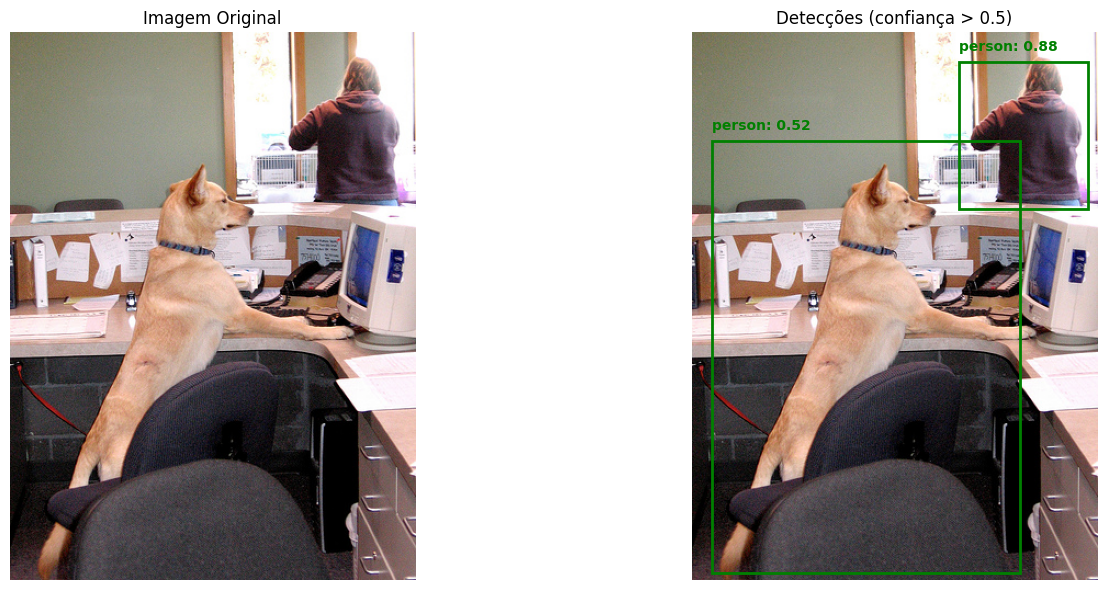

✅ Saved: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/resultados/detection_results.json
✅ Results saved: /home/icarus/cv-learning-lab/Deep_Learning_com_Transferencia/02_Deteccao_e_Segmentacao_com_Transfer_Learning/02_Reproduzindo_Deteccao_ou_Segmentacao_com_TL/resultados/detection_results.json


In [9]:
if TRAIN_IMG_DIR.exists():
    print("\n" + "="*70)
    print("🔍 INFERENCE AND EVALUATION")
    print("="*70)
    
    # Load trained model for inference
    detection_model.eval()
    
    # Perform inference on a sample - use DETECTION_DEVICE (CPU)
    with torch.no_grad():
        sample_idx = 0
        sample = train_dataset[sample_idx]
        # Normalize and move to detection device
        sample_image = (sample['image'].float() / 255.0).unsqueeze(0).to(DETECTION_DEVICE)
        
        # Get predictions
        predictions = detection_model(sample_image)
        pred_boxes = predictions[0]['boxes'].cpu().numpy()
        pred_scores = predictions[0]['scores'].cpu().numpy()
        pred_labels = predictions[0]['labels'].cpu().numpy()
    
    # Filter by confidence threshold
    confidence_threshold = 0.5
    mask = pred_scores > confidence_threshold
    filtered_boxes = pred_boxes[mask]
    filtered_scores = pred_scores[mask]
    filtered_labels = pred_labels[mask]
    
    print(f"\n📊 Sample Inference Results:")
    print(f"   Total detections: {len(pred_boxes)}")
    print(f"   High-confidence detections (>{confidence_threshold}): {len(filtered_boxes)}")
    print(f"   Classes detected: {np.unique(filtered_labels).tolist()}")
    
    # Visualize predictions
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Original image
    original_image = sample['image'].permute(1, 2, 0).numpy().astype(np.uint8)
    axes[0].imshow(original_image)
    axes[0].set_title("Imagem Original")
    axes[0].axis('off')
    
    # Image with predictions
    axes[1].imshow(original_image)
    
    # Draw predicted boxes
    for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, 
                                linewidth=2, edgecolor='g', facecolor='none')
        axes[1].add_patch(rect)
        
        class_name = train_dataset.category_id_to_name.get(label, f"Class {label}")
        axes[1].text(x1, y1-10, f'{class_name}: {score:.2f}', 
                    color='green', fontsize=10, weight='bold')
    
    axes[1].set_title(f"Detecções (confiança > {confidence_threshold})")
    axes[1].axis('off')
    
    plt.tight_layout()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "predicoes_visualizadas.png", dpi=100, bbox_inches='tight')
    print(f"\n✅ Visualization saved: {OUTPUT_DIR / 'predicoes_visualizadas.png'}")
    plt.show()
    
    # Save detection results
    detection_results = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "model": "Faster R-CNN ResNet50",
        "num_classes": num_classes,
        "class_names": list(train_dataset.category_id_to_name.values()),
        "sample_detections": {
            "total": int(len(pred_boxes)),
            "high_confidence": int(len(filtered_boxes)),
            "confidence_threshold": confidence_threshold
        }
    }
    save_json(detection_results, OUTPUT_DIR / "detection_results.json")
    print(f"✅ Results saved: {OUTPUT_DIR / 'detection_results.json'}")

## 8. Conclusões e Próximos Passos

### ✅ Aprendizados Principais

1. **Detecção é mais complexa que classificação**
   - Precisa localizar (bounding boxes) E classificar
   - Faster R-CNN combina RPN + classificação eficientemente

2. **Transfer Learning é crítico em detecção**
   - COCO pre-training acelera convergência
   - Fine-tuning em dados específicos leva horas vs. semanas

3. **Métricas de detecção:**
   - **mAP (mean Average Precision):** métrica padrão
   - Depende de IoU (Intersection over Union)

### 🎯 Próximos Passos

1. **Aumente dados:** Use dataset completo em vez de --quick
2. **Fine-tune tudo:** Descomente "freeze backbone" para melhor accuracy
3. **Experimente arquiteturas:** Teste Mask R-CNN (com segmentação pixel-perfeita)
4. **Production:** Deploy com TorchServe ou ONNX para inferência rápida